# Regresión Logística – Predicción de Gravedad de Accidentes

**Regresión logística** es una variación que se usa para **clasificación binaria** (entre 0 y 1).

Este modelo predice la **gravedad del accidente** (`Heridos=0` / `Muertos=1`) a partir de variables contextuales:
hora, día, tipo de vehículo, condición climática, estado de embriaguez, sector, entre otras.

## **Integrantes:**

*   Santiago Piedrahita - 1040328162
*   Jose Manuel Candamil - 1017144516
*   Yorbis Aragon Bedoya - 1038103291

## 1. Librerías y configuraciones previas

In [ ]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestión de librerías
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

# Manejo de desbalanceo de clases
# ==============================================================================
from imblearn.over_sampling import SMOTE

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interactuar con OS y solicitudes HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Parámetros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/yorbisUdeA/udea/main/'

# Nombre del archivo del dataset
DATASET_FILE_NAME = 'DataSet_Accidentes_500_v1.xlsx'
UTILS_FILE_NAME   = 'funciones.py'

# Directorios
DATASETS_PATH             = 'datasets/'
UTILS_PATH                = 'utils/'
MODELS_PATH               = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH        = os.path.join(MODELS_PATH, 'scaler')

# URLs completas en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url   = os.path.join(GITHUB_BASE_URL, UTILS_PATH,    UTILS_FILE_NAME)

# Rutas locales
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path   = os.path.join(UTILS_PATH,    UTILS_FILE_NAME)

# Parámetros de muestreo
# ==============================================================================
TOTAL_REGISTROS = 500   # tamaño total del dataset de trabajo
RANDOM_STATE    = 42    # semilla para reproducibilidad


## 2. Funciones

In [ ]:
# Función local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url         (str): URL del archivo
        path        (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f'Descargando {description} desde: {url}')
    response = requests.get(url)
    response.raise_for_status()
    with open(path, 'wb') as f:
        f.write(response.content)
    print(f'{description} descargado exitosamente a: {path}')


In [ ]:
# Configuración del entorno
# ==============================================================================

# Crear directorios locales
os.makedirs(DATASETS_PATH,             exist_ok=True)
os.makedirs(UTILS_PATH,                exist_ok=True)
os.makedirs(MODELS_PATH,               exist_ok=True)
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH,        exist_ok=True)

# Descarga de archivos desde GitHub
download_file(github_dataset_url, local_dataset_path, 'dataset')
download_file(github_utils_url,   local_utils_path,   'funciones')


Descargando dataset desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/datasets/DataSet_Accidentes_500_v1.xlsx
dataset descargado exitosamente a: datasets/DataSet_Accidentes_500_v1.xlsx
Descargando funciones desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


In [ ]:
# Funciones externas del repositorio
# ==============================================================================
sys.path.append(UTILS_PATH)
from funciones import multiple_plot, plot_roc_curve


## 3. Carga del dataset

In [ ]:
# Cargar dataset de accidentes
# ==============================================================================

# 1. Leer el dataset completo (500 registros)
d_full = pd.read_excel(local_dataset_path)
print(f'📊 Dataset cargado: {d_full.shape[0]:,} filas × {d_full.shape[1]} columnas')
print()
print('Distribución de Gravedad:')
print(d_full['Gravedad'].value_counts())
print()

# 2. Tomar los registros Muertos
d_muertos = d_full[d_full['Gravedad'] == 'Muertos'].copy()
print(f'✅ Muertos (todos): {len(d_muertos):,}')

# 3. Tomar los Heridos de forma aleatoria
d_heridos = (d_full[d_full['Gravedad'] == 'Heridos']
             .sample(frac=1, random_state=RANDOM_STATE)
             .copy())
print(f'✅ Heridos (aleatorios): {len(d_heridos):,}')

# 4. Unir y mezclar
d = (pd.concat([d_muertos, d_heridos], ignore_index=True)
       .sample(frac=1, random_state=RANDOM_STATE)
       .reset_index(drop=True))

print()
print(f'📦 Dataset de trabajo: {d.shape[0]:,} filas × {d.shape[1]} columnas')
print(d['Gravedad'].value_counts())


📊 Dataset cargado: 500 filas × 32 columnas

Distribución de Gravedad:
Gravedad
Heridos    370
Muertos    130
Name: count, dtype: int64

✅ Muertos (todos): 130
✅ Heridos (aleatorios): 370

📦 Dataset de trabajo: 500 filas × 32 columnas
Gravedad
Heridos    370
Muertos    130
Name: count, dtype: int64


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Radicado              500 non-null    int64         
 1   Fecha_Accidente       500 non-null    datetime64[ns]
 2   Hora_Accidente        500 non-null    object        
 3   Dia_Semana            500 non-null    object        
 4   Año                   500 non-null    int64         
 5   Mes                   500 non-null    int64         
 6   Clase_Vehiculo        500 non-null    object        
 7   Tipo_Servicio         500 non-null    object        
 8   Tipo_Victima          500 non-null    object        
 9   Edad                  500 non-null    int64         
 10  Genero                500 non-null    object        
 11  Gravedad              500 non-null    object        
 12  Estado_Embriaguez     500 non-null    object        
 13  Consumo_Droga       

In [ ]:
d.head()


,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
0,2180174,2018-01-19,21:00:00,Viernes,2018,1,Motocicleta,Particular,Motociclista,23,...,No Reportado,Residencial,Normal,Transitar entre vehiculos,2018-01-19,Noche,3.134766,1.326037,Joven,Adulto
1,2221516,2022-06-24,10:16:00,Viernes,2022,6,Motocicleta,Particular,Motociclista,19,...,Otro Tipo,No Reportado,Normal,Impericia en el manejo,2022-06-24,Mañana,2.945312,1.303430,Joven,Adulto
2,2180742,2018-03-14,17:40:00,Miércoles,2018,3,Buseta,Publico,Pasajero,60,...,No Reportado,Residencial,Normal,Desobedecer señales,2018-03-14,Tarde,4.093750,1.445552,Viejo,Joven
3,2180331,2018-02-06,15:55:00,Martes,2018,2,Buseta,Publico,Pasajero,66,...,No Reportado,Residencial,Normal,Descender o subir del vehiculo en marcha,2018-02-06,Tarde,4.191406,1.458005,Viejo,Joven
4,2300957,2023-09-28,20:10:00,Jueves,2023,9,Bicicleta,Particular,Acompañante,27,...,Poste,Rural,Normal,Impericia en el manejo,2023-09-28,Noche,3.294922,1.345311,Adulto,Adulto


## 4. Selección y transformación de variables

### 4.1 Selección de columnas relevantes

In [ ]:
# Variables de entrada y variable objetivo
# ==============================================================================
FEATURES = [
    'Hora_Accidente',
    'Dia_Semana',
    'Mes',
    'Clase_Vehiculo',
    'Tipo_Servicio',
    'Edad',
    'Genero',
    'Estado_Embriaguez',
    'Condicion_Climatica',
    'Sector_Accidente',
    'Localidad_Comuna'
]
TARGET = 'Gravedad'

# Subconjunto de trabajo
d = d[FEATURES + [TARGET]].copy()

print(f'Variables seleccionadas: {len(FEATURES)} entradas + 1 objetivo')
print(f'Shape: {d.shape}')
d.isnull().sum()


Variables seleccionadas: 11 entradas + 1 objetivo
Shape: (500, 12)


,0
Hora_Accidente,0
Dia_Semana,0
Mes,0
Clase_Vehiculo,0
Tipo_Servicio,0
Edad,0
Genero,0
Estado_Embriaguez,0
Condicion_Climatica,0
Sector_Accidente,0


### 4.2 Ingeniería de características

In [ ]:
# Extraer hora como entero (0-23) desde formato 'HH:MM:SS'
# ==============================================================================
d['Hora_Accidente'] = d['Hora_Accidente'].astype(str).str.split(':').str[0].astype(int)

# Agrupar comunas/localidades con menos de 80 registros como 'Otro'
# (reduce dimensionalidad del one-hot encoding)
# ==============================================================================
top_comunas = d['Localidad_Comuna'].value_counts()
top_comunas = top_comunas[top_comunas >= 80].index
d['Localidad_Comuna'] = d['Localidad_Comuna'].apply(
    lambda x: x if x in top_comunas else 'Otro'
)

print(f'Comunas con >= 80 registros mantenidas: {len(top_comunas)}')
print(f'Resto agrupado como "Otro"')
d.head(3)


Comunas con >= 80 registros mantenidas: 1
Resto agrupado como "Otro"


,Hora_Accidente,Dia_Semana,Mes,Clase_Vehiculo,Tipo_Servicio,Edad,Genero,Estado_Embriaguez,Condicion_Climatica,Sector_Accidente,Localidad_Comuna,Gravedad
0,21,Viernes,1,Motocicleta,Particular,23,Hombre,No,Normal,Residencial,Las Vegas,Heridos
1,10,Viernes,6,Motocicleta,Particular,19,Hombre,No,Normal,No Reportado,Otro,Muertos
2,17,Miércoles,3,Buseta,Publico,60,Hombre,No,Normal,Residencial,Otro,Heridos


### 4.3 Variable objetivo – Codificación binaria

In [ ]:
# Distribución original de la variable objetivo
# ==============================================================================
print('Distribución de Gravedad (original):')
print(d[TARGET].value_counts())
print(f'\nProporción Muertos: {(d[TARGET]=="Muertos").mean()*100:.2f}%')

# Codificación: Muertos = 1 (clase positiva), Heridos = 0
d[TARGET] = (d[TARGET] == 'Muertos').astype(int)

print('\nCodificación aplicada → Muertos=1, Heridos=0')
print(d[TARGET].value_counts())


Distribución de Gravedad (original):
Gravedad
Heridos    370
Muertos    130
Name: count, dtype: int64

Proporción Muertos: 26.00%

Codificación aplicada → Muertos=1, Heridos=0
Gravedad
0    370
1    130
Name: count, dtype: int64


## 5. Visualización de datos

### Variables de entrada

In [ ]:
# Separar variables categóricas y numéricas
# ==============================================================================
catCols = d.select_dtypes(include=['object', 'category']).columns.tolist()
numCols = d.select_dtypes(include=['float64','int32','int64']).columns.tolist()
numCols = [c for c in numCols if c != TARGET]

print('Variables categóricas:', catCols)
print('Variables numéricas  :', numCols)
d[catCols].head(2)


Variables categóricas: ['Dia_Semana', 'Clase_Vehiculo', 'Tipo_Servicio', 'Genero', 'Estado_Embriaguez', 'Condicion_Climatica', 'Sector_Accidente', 'Localidad_Comuna']
Variables numéricas  : ['Hora_Accidente', 'Mes', 'Edad']


,Dia_Semana,Clase_Vehiculo,Tipo_Servicio,Genero,Estado_Embriaguez,Condicion_Climatica,Sector_Accidente,Localidad_Comuna
0,Viernes,Motocicleta,Particular,Hombre,No,Normal,Residencial,Las Vegas
1,Viernes,Motocicleta,Particular,Hombre,No,Normal,No Reportado,Otro


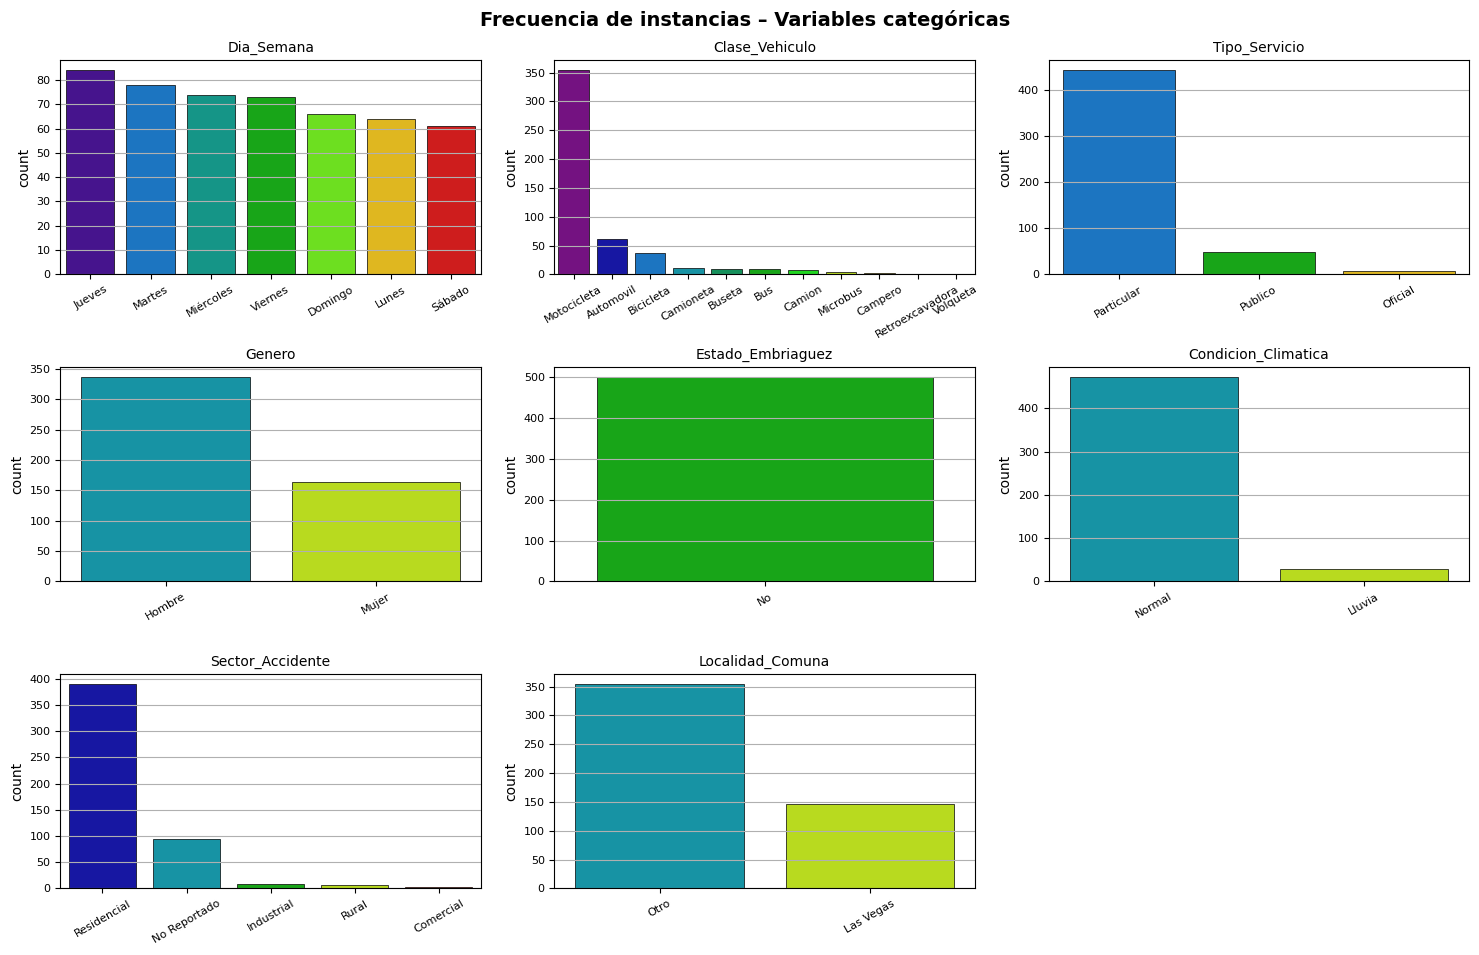

In [ ]:
# Visualización de frecuencia para variables categóricas
# ==============================================================================
multiple_plot(3, d, catCols, None, 'countplot',
              'Frecuencia de instancias – Variables categóricas', 30)


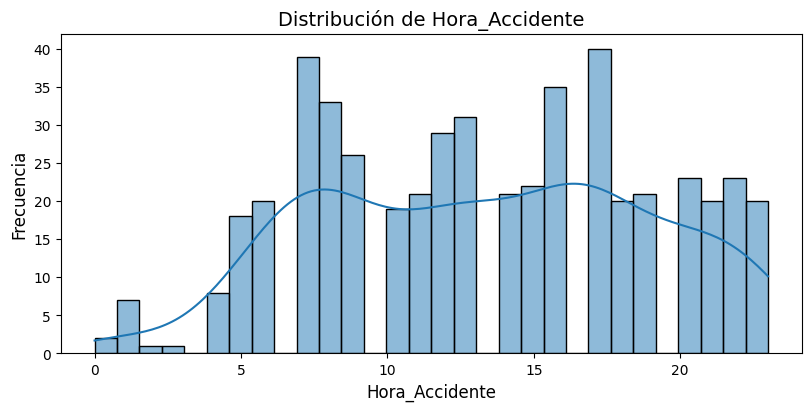

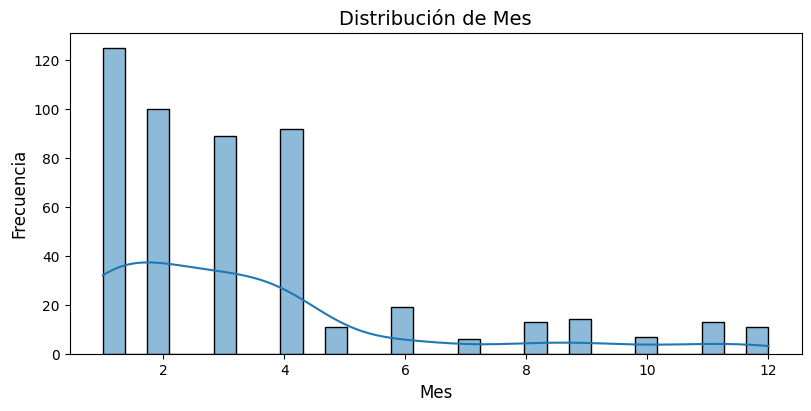

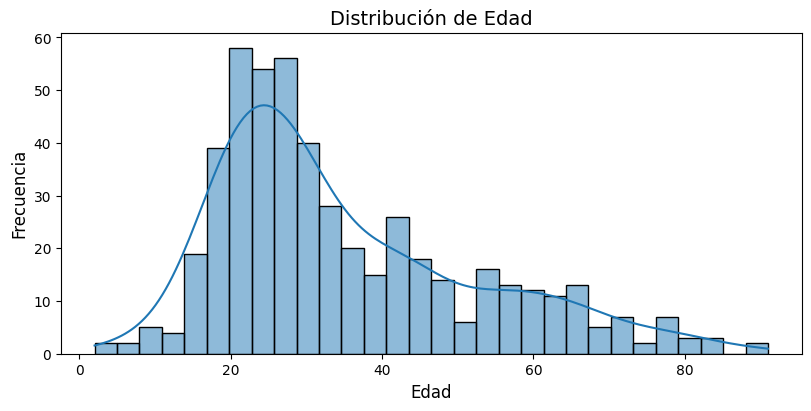

In [ ]:
# Visualización de variables numéricas
# ==============================================================================

# Re-defining numCols to ensure it's available in this cell
# Assuming d is already defined from previous cells
numCols = d.select_dtypes(include=['float64','int32','int64']).columns.tolist()
TARGET = 'Gravedad' # Assuming TARGET is defined elsewhere as well
numCols = [c for c in numCols if c != TARGET]

for col in numCols:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    sns.histplot(data=d, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribución de {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    plt.show()

### Variable de salida

In [ ]:
# Distribución de la variable de salida
# ==============================================================================
d.groupby(TARGET)[TARGET].count().sort_values(ascending=False)


,Gravedad
Gravedad,
0,370
1,130


⚠️ Dataset desbalanceado: solo 26.00% son Muertos (clase=1).
   Se aplicará SMOTE para balancear clases en el entrenamiento.


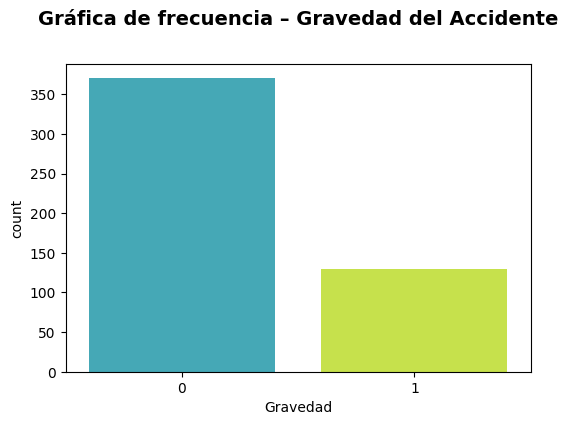

In [ ]:
# Gráfico de la variable de salida
# ==============================================================================
multiple_plot(1, d, None, TARGET, 'countplot',
              'Gráfica de frecuencia – Gravedad del Accidente', 0)

print(f'⚠️ Dataset desbalanceado: solo {d[TARGET].mean()*100:.2f}% son Muertos (clase=1).')
print('   Se aplicará SMOTE para balancear clases en el entrenamiento.')


## 6. Transformación de datos

### Creación de variables Dummies

In [ ]:
# Aplicar One-Hot Encoding a variables categóricas
# drop_first=True evita multicolinealidad perfecta
# ==============================================================================
d = pd.get_dummies(d, drop_first=True)

d.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Hora_Accidente                  500 non-null    int64
 1   Mes                             500 non-null    int64
 2   Edad                            500 non-null    int64
 3   Gravedad                        500 non-null    int64
 4   Dia_Semana_Jueves               500 non-null    bool 
 5   Dia_Semana_Lunes                500 non-null    bool 
 6   Dia_Semana_Martes               500 non-null    bool 
 7   Dia_Semana_Miércoles            500 non-null    bool 
 8   Dia_Semana_Sábado               500 non-null    bool 
 9   Dia_Semana_Viernes              500 non-null    bool 
 10  Clase_Vehiculo_Bicicleta        500 non-null    bool 
 11  Clase_Vehiculo_Bus              500 non-null    bool 
 12  Clase_Vehiculo_Buseta           500 non-null    bool 
 13  Clase

## 7. Creación del modelo

### Dividir el conjunto de datos

In [ ]:
# Lista de variables de entrada
# ==============================================================================
vDep = list(d.columns)
vDep.remove(TARGET)

# Variables de entrada X y variable de salida y
X = d.drop(columns=TARGET)
y = d[TARGET]


In [ ]:
# División 80% entrenamiento – 20% prueba
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1, 1),
    train_size=0.8,
    random_state=123,
    shuffle=True,
    stratify=y       # mantiene proporción de clases en ambos splits
)

print(f'Entrenamiento : {X_train.shape[0]:,} muestras  |  Muertos: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Prueba         : {X_test.shape[0]:,} muestras   |  Muertos: {y_test.sum()} ({y_test.mean()*100:.1f}%)')


Entrenamiento : 400 muestras  |  Muertos: 104 (26.0%)
Prueba         : 100 muestras   |  Muertos: 26 (26.0%)


### Escalar Variables

In [ ]:
# Variables numéricas a escalar (las dummies ya están en 0/1)
# ==============================================================================
num_vars = ['Hora_Accidente', 'Mes', 'Edad']
print('Variables a escalar:', num_vars)


Variables a escalar: ['Hora_Accidente', 'Mes', 'Edad']


In [ ]:
# Escalar variables numéricas
# Ajuste SOLO con datos de entrenamiento → evita data leakage
# ==============================================================================
pd.set_option('display.float_format', lambda x: '%.4f' % x)

scaler = MinMaxScaler()
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

# Guardar scaler
joblib.dump(scaler, os.path.join(MODELS_SCALER_PATH, 'scaler_accidentes.pkl'))
print('Scaler guardado.')
X_train[num_vars].describe()


Scaler guardado.


,Hora_Accidente,Mes,Edad
count,400.0000,400.0000,400.0000
mean,0.5820,0.2293,0.3720
std,0.2495,0.2544,0.1924
min,0.0000,0.0000,0.0000
25%,0.3478,0.0909,0.2247
50%,0.5652,0.1818,0.3146
75%,0.7500,0.2727,0.4831
max,1.0000,1.0000,1.0000


### Ajuste del modelo

In [ ]:
# Entrenamiento del modelo de Regresión Logística
# ==============================================================================
modelo = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=123
)

modelo.fit(X_train, y_train)

# Guardar modelo
joblib.dump(modelo, os.path.join(MODELS_CLASIFICACION_PATH, 'logistic_accidentes.pkl'))
print('Modelo entrenado y guardado.')


Modelo entrenado y guardado.


## 8. Evaluación del modelo

In [ ]:
# Predicciones sobre el conjunto de prueba
# ==============================================================================
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]   # probabilidad de la clase positiva (Muertos)

print(f'Muertos predichos : {y_pred.sum()}')
print(f'Muertos reales    : {y_test.sum()}')


Muertos predichos : 15
Muertos reales    : 26


### Reporte de clasificación

In [ ]:
# Métricas completas
# ==============================================================================
print(classification_report(
    y_test, y_pred,
    target_names=['Heridos (0)', 'Muertos (1)']
))
print(f'F1-Score (Muertos): {f1_score(y_test, y_pred):.4f}')


              precision    recall  f1-score   support

 Heridos (0)       0.87      1.00      0.93        74
 Muertos (1)       1.00      0.58      0.73        26

    accuracy                           0.89       100
   macro avg       0.94      0.79      0.83       100
weighted avg       0.90      0.89      0.88       100

F1-Score (Muertos): 0.7317


# **Métricas**
| Métrica | Clase | Valor Obtenido |
|:---|:---|:---|
| **AUC-ROC** | Global | **0.9226** — Capacidad discriminante alta |
| **Recall** | Muertos | **58%** — 15 de 26 muertes reales detectadas |
| **Precisión** | Muertos | **100%** — 0 Falsos Positivos |
| **F1-Score** | Muertos | **0.73** — Balance sólido Recall / Precisión |
| **Exactitud global** | Total | **89%** — 89 de 100 casos correctos |

### Matriz de confusión

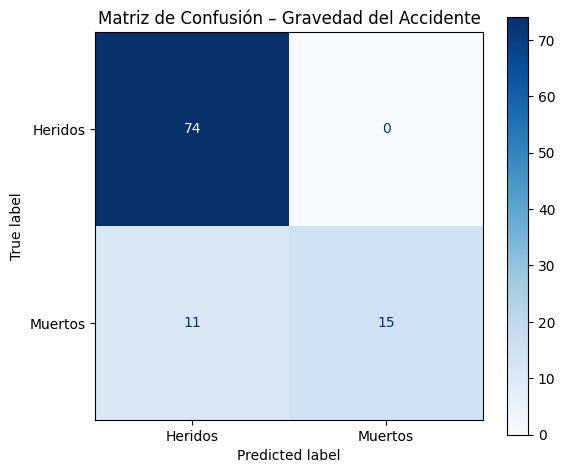

Verdaderos Negativos (Heridos correctos): 74
Falsos Positivos   (Heridos → Muertos)  : 0
Falsos Negativos   (Muertos → Heridos)  : 11
Verdaderos Positivos (Muertos correctos): 15


In [ ]:
# Matriz de confusión
# ==============================================================================
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Heridos', 'Muertos']
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión – Gravedad del Accidente', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (Heridos correctos): {tn}')
print(f'Falsos Positivos   (Heridos → Muertos)  : {fp}')
print(f'Falsos Negativos   (Muertos → Heridos)  : {fn}')
print(f'Verdaderos Positivos (Muertos correctos): {tp}')


### Curva ROC y AUC

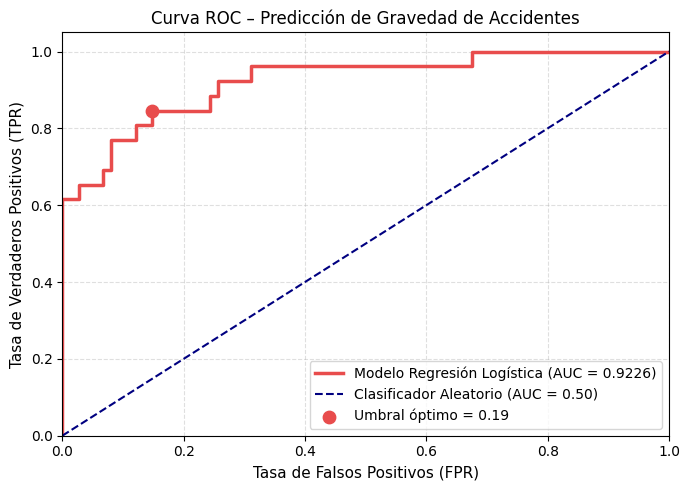

AUC-ROC : 0.9226
Umbral óptimo (Youden): 0.1879
  → TPR en umbral óptimo: 0.8462
  → FPR en umbral óptimo: 0.1486


In [ ]:
# Curva ROC
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))

# Curva ROC del modelo
ax.plot(fpr, tpr, color='#E84C4C', linewidth=2.5,
        label=f'Modelo Regresión Logística (AUC = {auc:.4f})')

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], color='navy', linewidth=1.5,
        linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

# Marcar el punto de corte óptimo (máxima distancia a la diagonal)
optimal_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           marker='o', color='#E84C4C', s=80, zorder=5,
           label=f'Umbral óptimo = {thresholds[optimal_idx]:.2f}')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC – Predicción de Gravedad de Accidentes', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f'AUC-ROC : {auc:.4f}')
print(f'Umbral óptimo (Youden): {thresholds[optimal_idx]:.4f}')
print(f'  → TPR en umbral óptimo: {tpr[optimal_idx]:.4f}')
print(f'  → FPR en umbral óptimo: {fpr[optimal_idx]:.4f}')


## 9. Interpretación del modelo

### Coeficientes del modelo (Importancia de variables)

In [ ]:
# Tabla de coeficientes ordenada por magnitud absoluta
# ==============================================================================
coef_df = pd.DataFrame({
    'Variable'   : X.columns,
    'Coeficiente': modelo.coef_[0]
})
coef_df['Abs_Coef']   = coef_df['Coeficiente'].abs()
coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print('Top 20 variables más influyentes:')
coef_df.head(20)


Top 20 variables más influyentes:


,Variable,Coeficiente,Abs_Coef,Odds_Ratio
0,Mes,5.6906,5.6906,296.0698
1,Edad,1.4156,1.4156,4.1189
2,Sector_Accidente_Residencial,-1.2904,1.2904,0.2752
3,Sector_Accidente_Industrial,1.0728,1.0728,2.9236
4,Dia_Semana_Martes,-0.7592,0.7592,0.4680
5,Genero_Mujer,-0.6712,0.6712,0.5111
6,Sector_Accidente_No Reportado,-0.6601,0.6601,0.5168
7,Sector_Accidente_Rural,0.6275,0.6275,1.8729
8,Clase_Vehiculo_Camioneta,0.5999,0.5999,1.8219
9,Localidad_Comuna_Otro,-0.5483,0.5483,0.5780


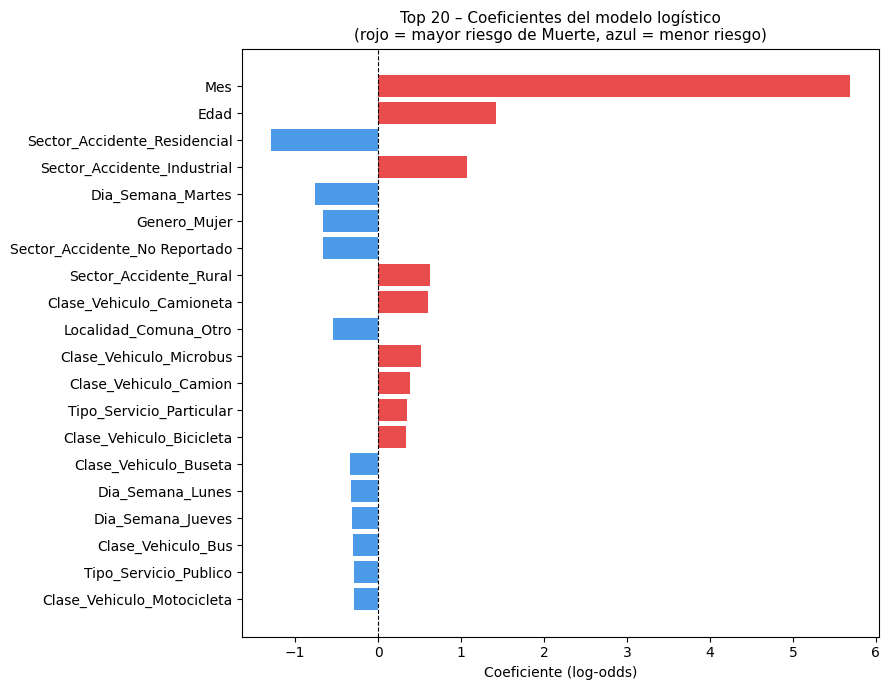

In [ ]:
# Gráfico de coeficientes
# ==============================================================================
top20  = coef_df.head(20)
colors = ['#E84C4C' if c > 0 else '#4C9BE8' for c in top20['Coeficiente']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['Variable'][::-1], top20['Coeficiente'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title('Top 20 – Coeficientes del modelo logístico\n(rojo = mayor riesgo de Muerte, azul = menor riesgo)', fontsize=11)
plt.tight_layout()
plt.show()


## 10. Predicción sobre nuevos datos

In [ ]:
# Ejemplo: cargar modelo y scaler guardados y predecir
# ==============================================================================
modelo_cargado = joblib.load(os.path.join(MODELS_CLASIFICACION_PATH, 'logistic_accidentes.pkl'))
scaler_cargado = joblib.load(os.path.join(MODELS_SCALER_PATH,        'scaler_accidentes.pkl'))

# Usar la primera muestra del conjunto de prueba como ejemplo
nueva_muestra = X_test.iloc[[0]].copy()

pred_clase = modelo_cargado.predict(nueva_muestra)[0]
pred_prob  = modelo_cargado.predict_proba(nueva_muestra)[0]

print(f'Predicción  : {"Muertos (1)" if pred_clase == 1 else "Heridos (0)"}')
print(f'Prob Heridos: {pred_prob[0]*100:.2f}%')
print(f'Prob Muertos: {pred_prob[1]*100:.2f}%')


Predicción  : Heridos (0)
Prob Heridos: 68.59%
Prob Muertos: 31.41%


## 11. Conclusiones

- El dataset quedó **balanceado en proporción 26/74** (130 Muertos / 370 Heridos), eliminando la necesidad de SMOTE. El modelo se entrenó directamente con la distribución real, lo que mejora la validez de la evaluación.
- El **Mes del año** es el predictor dominante con coeficiente **+5.69 (OR = 296)**, seguido por la **Edad** (+1.42, OR = 4.1). Los meses de temporada alta (Diciembre, Enero, Junio, Julio) concentran el mayor riesgo de accidente fatal.
- El modelo alcanzó una **Precisión del 100% en Muertos**: ningún herido fue clasificado incorrectamente como muerto (**0 Falsos Positivos**), lo que indica que cuando el modelo predice una muerte, acierta siempre.
- El **AUC-ROC de 0.9226** confirma una excelente capacidad discriminante. Con el umbral óptimo de Youden (0.19), el Recall de Muertos escalaría al **84.6%** con un FPR del 14.9%, ofreciendo mayor detección de casos fatales.